In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\shikh\AppData\Local\Temp\ipykernel_8380\4059976664.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="sentiment_label", palette="pastel")


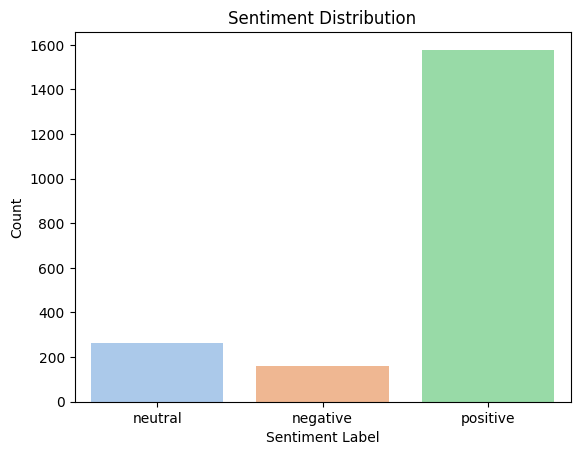

In [2]:
# Load cleaned data
df = pd.read_csv("C:/Users/shikh/Downloads/Projects/Duolingo/duolingo-analysis/0_data/cleaned/duolingo_reviews_cleaned.csv")

# Plot sentiment label distribution
sns.countplot(data=df, x="sentiment_label", palette="pastel")
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment Label")
plt.ylabel("Count")
plt.show()

C:\Users\shikh\AppData\Local\Temp\ipykernel_8380\3165919407.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='sentiment_label', y='review_length', palette="muted")


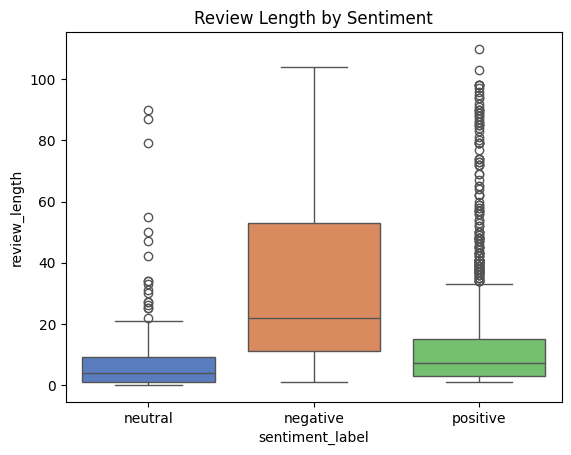

In [4]:
df['review_length'] = df['cleaned_content'].apply(lambda x: len(str(x).split()) if pd.notnull(x) else 0)


sns.boxplot(data=df, x='sentiment_label', y='review_length', palette="muted")
plt.title("Review Length by Sentiment")
plt.show()


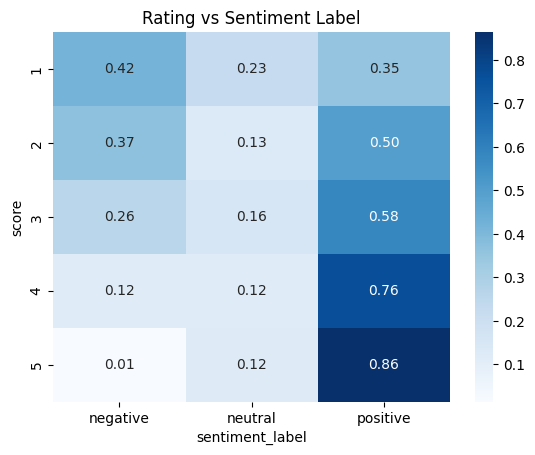

In [5]:
pivot = pd.crosstab(df['score'], df['sentiment_label'], normalize='index')
sns.heatmap(pivot, annot=True, cmap='Blues', fmt=".2f")
plt.title("Rating vs Sentiment Label")
plt.show()


In [6]:
df.to_csv("../0_data/cleaned/duolingo_reviews_with_length.csv", index=False)


C:\Users\shikh\AppData\Local\Temp\ipykernel_36644\2852117274.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='feature_mentioned', order=df['feature_mentioned'].value_counts().index, palette="pastel")


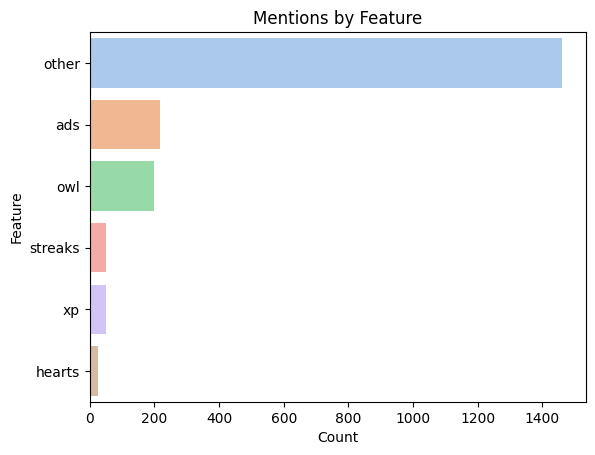

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("../0_data/cleaned/duolingo_reviews_tagged.csv")

sns.countplot(data=df, y='feature_mentioned', order=df['feature_mentioned'].value_counts().index, palette="pastel")
plt.title("Mentions by Feature")
plt.xlabel("Count")
plt.ylabel("Feature")
plt.show()


C:\Users\shikh\AppData\Local\Temp\ipykernel_36644\2786722156.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='feature_mentioned', y='sentiment_score', palette="muted")


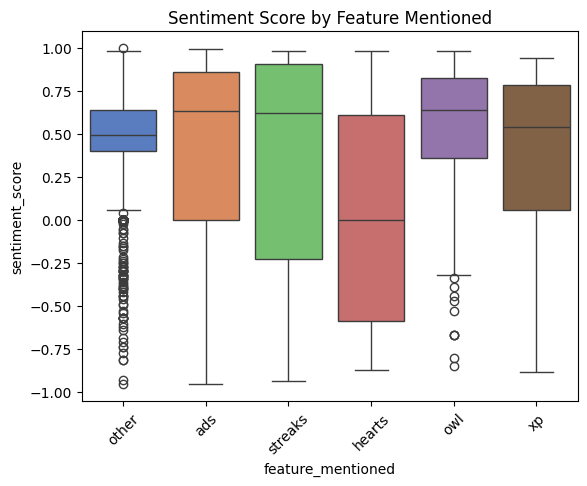

In [3]:
sns.boxplot(data=df, x='feature_mentioned', y='sentiment_score', palette="muted")
plt.title("Sentiment Score by Feature Mentioned")
plt.xticks(rotation=45)
plt.show()


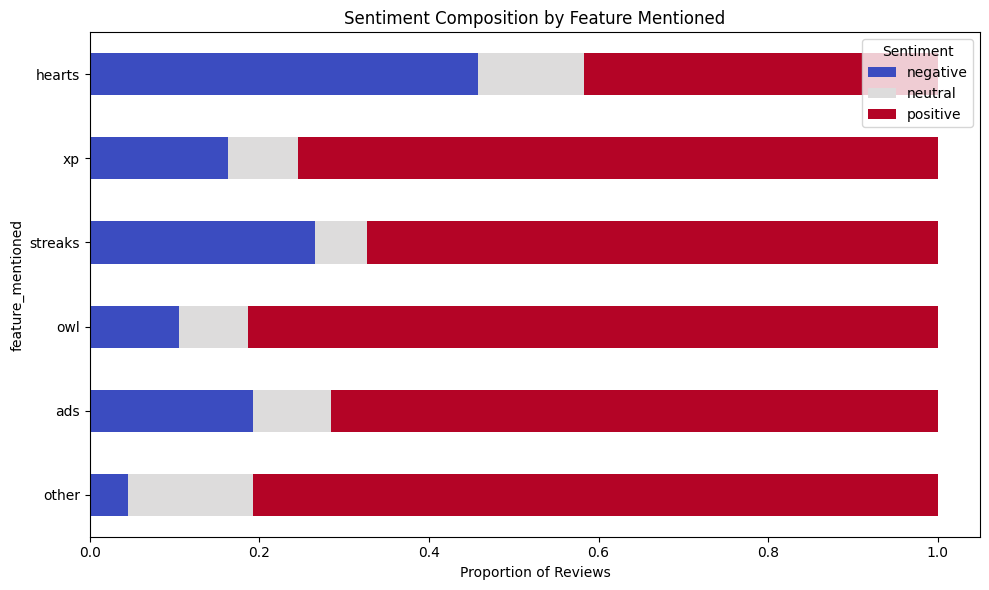

In [4]:
pivot = pd.crosstab(df['feature_mentioned'], df['sentiment_label'], normalize='index')
pivot = pivot.loc[df['feature_mentioned'].value_counts().index]  # sort by most mentioned

pivot.plot(kind='barh', stacked=True, colormap='coolwarm', figsize=(10,6))
plt.title("Sentiment Composition by Feature Mentioned")
plt.xlabel("Proportion of Reviews")
plt.legend(title="Sentiment")
plt.tight_layout()
plt.show()


In [5]:
plt.savefig("../visuals/sentiment_by_feature.png")


<Figure size 640x480 with 0 Axes>

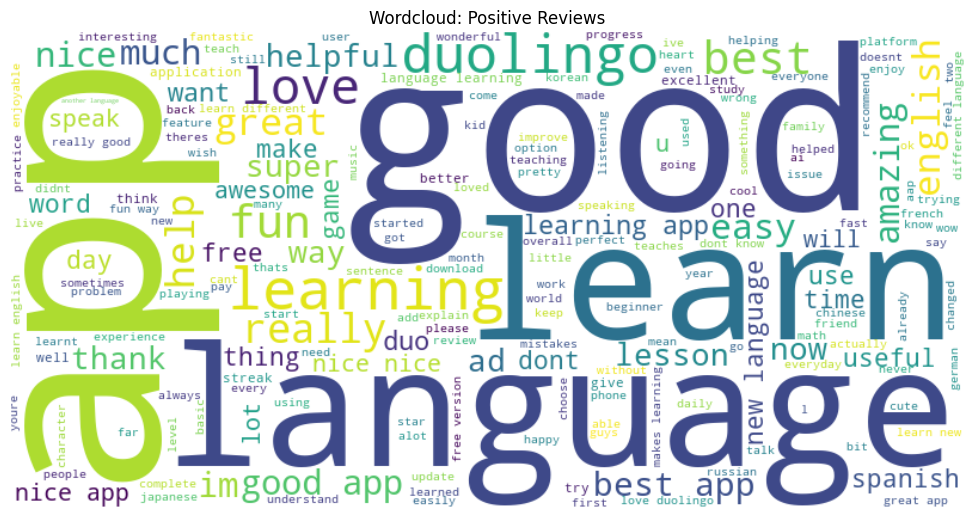

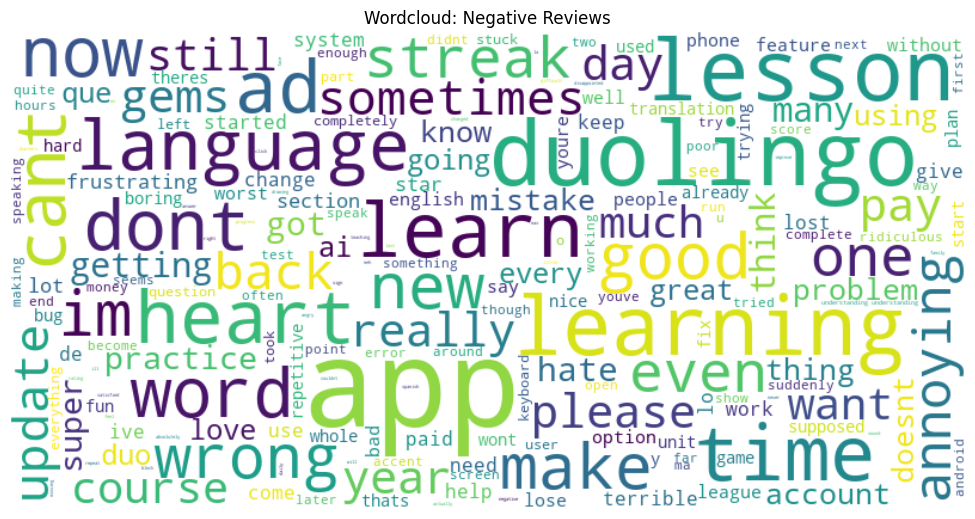

In [6]:
from wordcloud import WordCloud

def generate_wordcloud(text, title):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(" ".join(text))
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(title)
    plt.tight_layout(pad=0)
    plt.show()

# Positive reviews
positive_text = df[df['sentiment_label'] == 'positive']['cleaned_content']
generate_wordcloud(positive_text, "Wordcloud: Positive Reviews")

# Negative reviews
negative_text = df[df['sentiment_label'] == 'negative']['cleaned_content']
generate_wordcloud(negative_text, "Wordcloud: Negative Reviews")


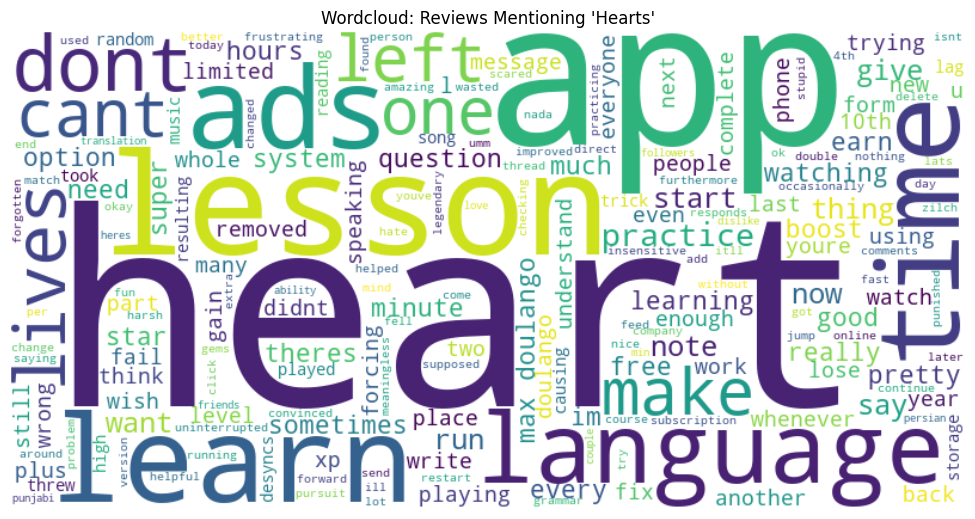

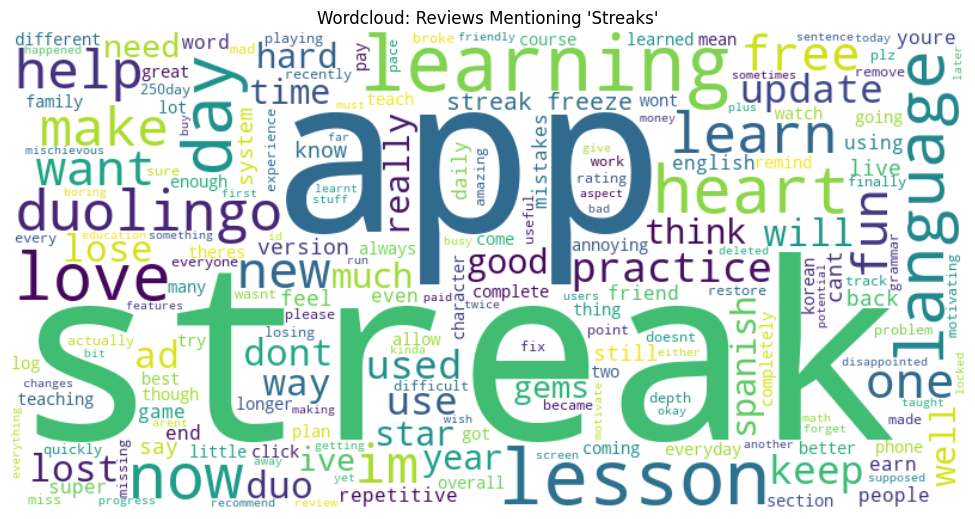

In [7]:
hearts_reviews = df[df['feature_mentioned'] == 'hearts']['cleaned_content']
generate_wordcloud(hearts_reviews, "Wordcloud: Reviews Mentioning 'Hearts'")

streak_reviews = df[df['feature_mentioned'] == 'streaks']['cleaned_content']
generate_wordcloud(streak_reviews, "Wordcloud: Reviews Mentioning 'Streaks'")


In [27]:
import pandas as pd
import plotly.graph_objects as go

# Define your subjective scores (1–5) based on review analysis
octalysis_scores = {
    "Epic Meaning": 4,
    "Accomplishment": 5,
    "Creativity/Feedback": 3,
    "Ownership": 4,
    "Social Influence": 2,
    "Scarcity": 3,
    "Curiosity": 4,
    "Avoidance": 5
}

# Create radar chart
labels = list(octalysis_scores.keys())
scores = list(octalysis_scores.values())

fig = go.Figure(data=go.Scatterpolar(
      r=scores,
      theta=labels,
      fill='toself'
))

fig.update_layout(
  polar=dict(
    radialaxis=dict(
      visible=True,
      range=[0, 5]
    )),
  showlegend=False,
  title="Duolingo Gamification Scorecard (Octalysis)"
)

fig.show()
